<a href="https://colab.research.google.com/github/eunseojeon/AI_Coding_for_Autonomous_Driving_Class/blob/main/0804_day1_%EC%B9%BC%EB%A7%8C%ED%95%84%ED%84%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 1 Lab: 칼만필터와 데이터 추적기법 (Kalman Filter and Data Tracking)
이 노트북은 자율주행 데이터 처리 강의의 첫 번째 실습입니다. 각 실습은 Python 표준 라이브러리, NumPy, matplotlib만 사용하며, 센서 데이터의 노이즈 보정과 융합을 다룹니다.


## Lab 1: 1D 칼만필터로 노이즈 위치 데이터 보정하기

**목표:**
- 노이즈가 섞인 1차원 위치 데이터를 Kalman Filter로 보정합니다.
- Python 표준 라이브러리만 사용합니다.

**단계:**
1. `random.gauss`로 노이즈가 있는 위치 데이터 10개를 생성하세요.
2. 칼만필터의 예측-갱신 과정을 코드로 구현하세요.
3. 보정된 최종 위치 추정값을 출력하세요.

**예상 출력:**
- 보정 전 위치 리스트, 보정 후 최종 추정값


In [ ]:
# 1D 칼만필터 예제 (Python 표준 라이브러리)
import random

# Step 1: 노이즈가 있는 위치 데이터 생성
true_position = 0
measured_positions = [true_position + random.gauss(0, 1) for _ in range(10)]
print('측정 위치:', measured_positions)

# Step 2: 칼만필터 초기값 설정
estimate = 0
estimate_error = 1
measurement_error = 1

# Step 3: 예측-갱신 반복
for z in measured_positions:
    # 예측 (Prediction)
    predicted_estimate = estimate
    predicted_estimate_error = estimate_error

    # 갱신 (Update)
    kalman_gain = predicted_estimate_error / (predicted_estimate_error + measurement_error)
    estimate = predicted_estimate + kalman_gain * (z - predicted_estimate)
    estimate_error = (1 - kalman_gain) * predicted_estimate_error

    # (선택) estimate_error 업데이트 생략 가능

print('최종 추정값:', estimate)

측정 위치: [1.920159391652145, -1.5606144917953089, -1.6142843952872277, -1.6756878747311243, 2.0766012007005696, -1.2031539631491608, -0.3496137544824443, -0.3564803714164583, -1.3028285936390502, -1.0043434562288076]
최종 추정값: -0.46093148257971517


1. 노이즈가 포함된 위치 측정 데이터 생성
- `true_position`은 실제 위치(여기선 0)입니다.
- `random.gauss(0, 1)`는 평균 0, 표준편차 - 1인 가우시안(정규분포) 노이즈를 생성합니다.
- 이를 통해 실제 위치 주위에 노이즈가 추가된 10개의 측정값(`measured_positions`)을 만듭니다.
- 즉, 현실에서 “센서에서 읽어온 값마다 잡음이 섞여 있다”는 상황을 시뮬레이션합니다.

2. 칼만 필터 초기값 설정
- `estimate`: 상태(위치)의 추정 시작값.
- `estimate_error`: 현재 추정값의 신뢰도(작을수록 더 신뢰).
- `measurement_error`: 측정에 포함된 노이즈 크기.

3. 예측-갱신(Prediction-Update) 반복
- 예측 단계: 이번 예제는 움직임이 없는 상수모델이므로, 이전 추정값을 그대로 예측값으로 사용합니다.
- 칼만 이득(Kalman Gain)
= (예측 오차)/(예측 오차 + 예측 오차)
- - 측정값과 예측값 중에서 어느 쪽을 더 신뢰할지 결정하는 가중치.
- - 예측 오차가 크면 측정값을 더 신뢰, 반대로 측정 오차가 크면 예측값을 더 신뢰.
- 갱신 단계: estimate = predicted_estimate + kalman_gain × (z − predicted_estimate)
- - 새 측정값 z와 예측값의 차이를 칼만 이득만큼 반영해서 추정값 보정.
estimate_error=(1−kalman_gain)× predicted_estimate_error
- - 추정값 오차는 갱신될수록 줄어듭니다(점점 더 신뢰).

---


## Lab 2: 센서 융합 (GPS + IMU) 가중 평균 실습

**목표:**
- GPS와 IMU(속도계) 데이터를 가중 평균으로 융합하여 더 정확한 위치를 추정합니다.
- Python 표준 라이브러리만 사용합니다.

**단계:**
1. `random.gauss`로 GPS 위치 데이터 10개, IMU 위치 데이터 10개를 각각 생성하세요.
2. 두 센서의 신뢰도를 다르게 설정하고(예: GPS: 0.6, IMU: 0.4), 가중 평균으로 융합하세요.
3. 융합 결과 리스트를 출력하세요.

**예상 출력:**
- GPS, IMU, 융합 위치 리스트

In [ ]:
# 센서 융합 (GPS + IMU) 가중 평균 예제
import random

# Step 1: GPS, IMU 위치 데이터 생성
true_position = 0
gps_positions = [true_position + random.gauss(0, 1) for _ in range(10)]
imu_positions = [true_position + random.gauss(0, 2) for _ in range(10)]

# Step 2: 신뢰도(가중치) 설정
w_gps = 0.6
w_imu = 0.4

# Step 3: 가중 평균 융합
fused_positions = [w_gps * gps + w_imu * imu for gps, imu in zip(gps_positions, imu_positions)]

print('GPS:', gps_positions)
print('IMU:', imu_positions)
print('융합:', fused_positions)

GPS: [-0.537812628098865, -0.9392051453787272, 1.36003281074085, 0.09249417863360006, -0.8503727105417905, -0.6039809690862854, -1.263239854219373, -1.759412991270506, 0.5270902357217419, -1.469928117215198]
IMU: [1.7471170604542647, 1.6335070589060623, 1.5615973029438406, -1.911359618229286, -2.9443125788044036, -0.1825719252900431, 0.1880372022870186, 1.5842756487363852, -0.3034062072144555, 1.7008835938470093]
융합: [0.376159247322387, 0.08987973633518864, 1.4406586076220462, -0.7090473401115543, -1.687948657846836, -0.4354173515677885, -0.6827290316168163, -0.42193753526774946, 0.19489165854726287, -0.201603432790315]


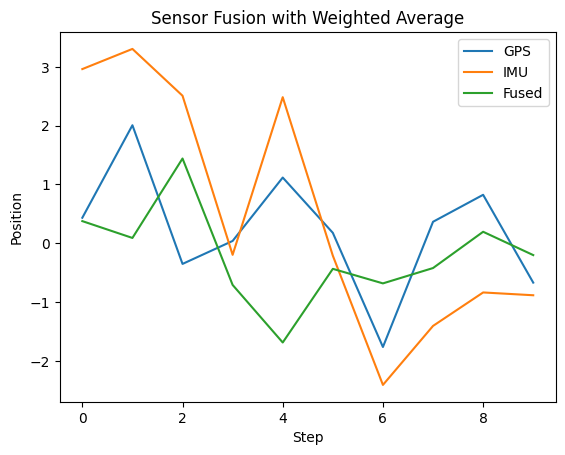

In [ ]:
# 센서 융합 (GPS + IMU) 가중 평균 예제
import random
import matplotlib.pyplot as plt

# Step 1: GPS, IMU 위치 데이터 생성
true_position = 0
gps_positions = [true_position + random.gauss(0, 1) for _ in range(10)]
imu_positions = [true_position + random.gauss(0, 2) for _ in range(10)]

# Step 2: 신뢰도(가중치) 설정
w_gps = 0.6
w_imu = 0.4

# Step 3: 가중 평균 융합
## FILL THIS

# Step 4: 시각화
plt.plot(gps_positions, label='GPS')
plt.plot(imu_positions, label='IMU')
plt.plot(fused_positions, label='Fused')
plt.legend()
plt.title('Sensor Fusion with Weighted Average')
plt.xlabel('Step')
plt.ylabel('Position')
plt.show()

## Lab 3: CSV 데이터에 칼만필터 적용 및 시각화

**목표:**
- CSV 파일(또는 생성된 데이터)에서 위치 데이터를 불러와 칼만필터로 보정하고, 결과를 시각화합니다.
- Python 표준 라이브러리, NumPy, matplotlib 사용

**단계:**
1. (선택) CSV 파일이 없으면 `random.gauss`로 데이터 생성
2. 칼만필터로 보정된 위치 계산
3. matplotlib으로 원본 vs. 보정 데이터 플롯

**예상 출력:**
- 원본/보정 위치 리스트, 플롯 이미지

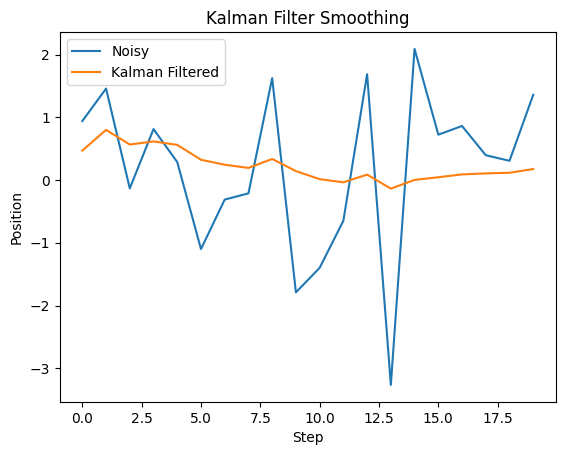

In [ ]:
# 칼만필터로 CSV(또는 생성) 데이터 보정 및 시각화
import random
import numpy as np
import matplotlib.pyplot as plt

# Step 1: 데이터 불러오기 또는 생성
try:
    import pandas as pd
    data = pd.read_csv('positions.csv')
    measured_positions = data['position'].tolist()
except Exception:
    measured_positions = [random.gauss(0, 1) for _ in range(20)]

# Step 2: 칼만필터 적용
estimate = 0
estimate_error = 1
measurement_error = 1
estimates = []
for z in measured_positions:
    # 예측 (Prediction)
    predicted_estimate = estimate
    predicted_estimate_error = estimate_error

    # 갱신 (Update)
    kalman_gain = predicted_estimate_error / (predicted_estimate_error + measurement_error)
    estimate = predicted_estimate + kalman_gain * (z - predicted_estimate)
    estimate_error = (1 - kalman_gain) * predicted_estimate_error
    estimates.append(estimate)


# Step 3: 시각화
plt.plot(measured_positions, label='Noisy')
plt.plot(estimates, label='Kalman Filtered')
plt.legend()
plt.title('Kalman Filter Smoothing')
plt.xlabel('Step')
plt.ylabel('Position')
plt.show()

---

### 오늘의 실습 정리
- 칼만필터로 노이즈 데이터 보정, 센서 융합, 시각화까지 경험했습니다.
- Colab에서 결과(플롯, 수치)를 저장해 제출하세요.
- 질문은 강의 포럼/이메일로!


In [ ]:
# 해보기

import random
# 실제 위치는 0, 노이즈가 섞인 측정값 10개 생성
measurements = [0 + random.gauss(0, 2.0) for _ in range(10)]
estimate = 0.0 # 초기 추정값
error_in_estimate = 1.0 # 초기 추정 오차
measurement_error = 1.0 # 측정 오차 (added this line as it was missing)
for z in measurements:
    # 예측 (Prediction) - Added these lines
    predicted_estimate = estimate
    predicted_estimate_error = error_in_estimate

    # 칼만 이득 계산
    K = predicted_estimate_error / (predicted_estimate_error + measurement_error)

    # 추정값 갱신
    estimate = predicted_estimate + K * (z - predicted_estimate)

    # 추정 오차 갱신
    error_in_estimate = (1 - K) * predicted_estimate_error

print(f"최종 추정값: {estimate:.2f}") # Corrected the print statement

최종 추정값: 0.49
